# Week 6 · Notebook 1 — Bayesian Neural Networks via Mean-Field VI

## Learning objectives

1. Specify a Bayesian neural network (BNN) with a Gaussian prior on weights.
2. Apply the reparameterisation trick to optimise a mean-field Gaussian posterior over weights (Bayes-by-backprop).
3. Implement a BNN regressor in PyTorch and visualise epistemic uncertainty on a 1-D dataset.
4. Compare against a deterministic MLP and against the GP from week 5.

---

## 1. The Bayesian neural network

A BNN places a prior over the weights $w$ of a neural network $f_w$:
$$
w \sim \mathcal{N}(0, \alpha^{-1} I),\qquad
y_n \mid x_n, w \sim \mathcal{N}\bigl(f_w(x_n), \sigma_n^2\bigr).
$$
The posterior $p(w\mid \mathcal{D})$ is intractable. Following Blundell et al. (2015, *Bayes by Backprop*), we use a factorised Gaussian variational posterior
$$
q_\phi(w) = \prod_i \mathcal{N}(w_i; \mu_i, \sigma_i^2),\qquad \sigma_i = \log(1 + e^{\rho_i})
$$
and maximise the ELBO with the reparameterisation trick (notebook 4.3).

The ELBO splits as
$$
\mathcal{L}(\phi) = \mathbb{E}_{q_\phi}\bigl[\log p(\mathcal{D}\mid w)\bigr] - \mathrm{KL}\bigl(q_\phi(w)\,\Vert\,p(w)\bigr).
$$
Both KL and likelihood terms are differentiable in $\phi$ once we write $w = \mu + \sigma\odot\epsilon$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

rng = np.random.default_rng(0)
torch.manual_seed(0)
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GREEN = '#5B7DB1', '#C46D5E', '#7CA982'


## 2. A `VariationalLinear` layer

Each parameter has a $(\mu, \rho)$ pair. Forward passes draw $w$ once per call; the KL contribution to the loss is computed analytically using
$$
\mathrm{KL}\bigl(\mathcal{N}(\mu, \sigma^2)\,\Vert\,\mathcal{N}(0, \sigma_0^2)\bigr)
= \log\frac{\sigma_0}{\sigma} + \frac{\sigma^2 + \mu^2}{2\sigma_0^2} - \frac12.
$$


In [2]:
class VarLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        self.in_features, self.out_features = in_features, out_features
        self.prior_sigma = prior_sigma
        self.w_mu = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        self.w_rho = nn.Parameter(torch.full((out_features, in_features), -3.0))
        self.b_mu = nn.Parameter(torch.zeros(out_features))
        self.b_rho = nn.Parameter(torch.full((out_features,), -3.0))

    def _sample(self):
        eps_w = torch.randn_like(self.w_mu)
        eps_b = torch.randn_like(self.b_mu)
        sig_w = torch.log1p(torch.exp(self.w_rho))
        sig_b = torch.log1p(torch.exp(self.b_rho))
        w = self.w_mu + sig_w * eps_w
        b = self.b_mu + sig_b * eps_b
        return w, b, sig_w, sig_b

    def forward(self, x):
        w, b, *_ = self._sample()
        return x @ w.T + b

    def kl(self):
        sig_w = torch.log1p(torch.exp(self.w_rho))
        sig_b = torch.log1p(torch.exp(self.b_rho))
        ps = self.prior_sigma
        kl_w = torch.log(ps/sig_w) + (sig_w**2 + self.w_mu**2)/(2*ps**2) - 0.5
        kl_b = torch.log(ps/sig_b) + (sig_b**2 + self.b_mu**2)/(2*ps**2) - 0.5
        return kl_w.sum() + kl_b.sum()


In [3]:
class BNN(nn.Module):
    def __init__(self, in_dim=1, hidden=32, prior_sigma=1.0):
        super().__init__()
        self.l1 = VarLinear(in_dim, hidden, prior_sigma)
        self.l2 = VarLinear(hidden, hidden, prior_sigma)
        self.l3 = VarLinear(hidden, 1, prior_sigma)

    def forward(self, x):
        h = torch.tanh(self.l1(x))
        h = torch.tanh(self.l2(h))
        return self.l3(h)

    def kl(self):
        return self.l1.kl() + self.l2.kl() + self.l3.kl()


## 3. Training data with a gap


In [4]:
def f_true(x): return x * np.sin(x)
X1 = rng.uniform(-5, -1, 25)
X2 = rng.uniform(2, 6, 25)
X_np = np.concatenate([X1, X2])
y_np = f_true(X_np) + 0.3*rng.normal(size=len(X_np))

X = torch.tensor(X_np.reshape(-1, 1), dtype=torch.float32)
y = torch.tensor(y_np.reshape(-1, 1), dtype=torch.float32)


## 4. Training loop

We compute the ELBO as $\mathcal{L} = \mathbb{E}_q[\log p(y\mid f_w(x))] - \mathrm{KL}$. The noise standard deviation $\sigma_n$ is learned alongside the variational parameters.


In [5]:
bnn = BNN(hidden=64, prior_sigma=1.0)
log_sn = nn.Parameter(torch.tensor(-1.0))
opt = torch.optim.Adam(list(bnn.parameters()) + [log_sn], lr=5e-3)

n_epochs = 3000
S = 1   # MC samples per gradient step
N = len(X)
hist = []
for ep in range(n_epochs):
    opt.zero_grad()
    nll = 0.0
    for _ in range(S):
        pred = bnn(X)
        sn = torch.exp(log_sn)
        nll = nll + 0.5*((y - pred)**2 / sn**2).sum() + N*torch.log(sn)
    nll = nll / S
    loss = nll + bnn.kl()
    loss.backward()
    opt.step()
    if ep % 200 == 0:
        hist.append(loss.item())
        print(f'ep {ep:4d}  loss = {loss.item():.2f}  sigma_n = {torch.exp(log_sn).item():.3f}')


ep    0  loss = 12489.10  sigma_n = 0.370


ep  200  loss = 7248.02  sigma_n = 0.672


ep  400  loss = 4394.85  sigma_n = 0.845


ep  600  loss = 2154.26  sigma_n = 1.054


ep  800  loss = 1048.50  sigma_n = 1.285


...

ep 2000  loss = 211.88  sigma_n = 2.850


ep 2200  loss = 185.35  sigma_n = 3.130


ep 2400  loss = 173.33  sigma_n = 3.426


ep 2600  loss = 156.34  sigma_n = 3.643


ep 2800  loss = 213.74  sigma_n = 3.861


## 5. Predictive distribution

For each test point we sample $S$ weight configurations from $q_\phi$ and aggregate the outputs:
$$
p(y_*\mid x_*, \mathcal{D}) \approx \frac{1}{S}\sum_{s=1}^S \mathcal{N}\bigl(y_*; f_{w^{(s)}}(x_*),\, \sigma_n^2\bigr).
$$
The variance of $f_{w^{(s)}}(x_*)$ across $s$ is the **epistemic** uncertainty; $\sigma_n^2$ is the **aleatoric** part (see notebook 6.3).


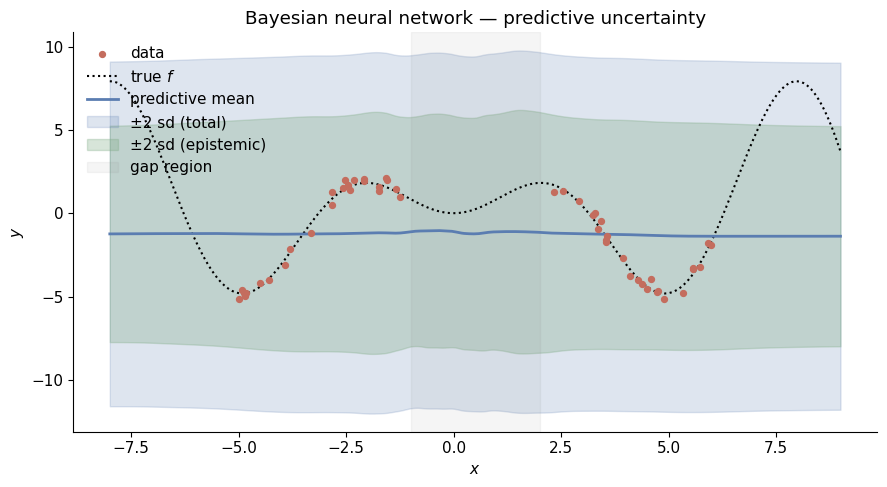

In [6]:
bnn.eval()
xs_np = np.linspace(-8, 9, 300)
Xs = torch.tensor(xs_np.reshape(-1, 1), dtype=torch.float32)
with torch.no_grad():
    preds = torch.stack([bnn(Xs).squeeze() for _ in range(200)], dim=0).numpy()
    sn_val = torch.exp(log_sn).item()
mu = preds.mean(axis=0)
sd_epi = preds.std(axis=0)
sd_total = np.sqrt(sd_epi**2 + sn_val**2)

plt.figure()
plt.scatter(X_np, y_np, color=RED, s=18, zorder=5, label='data')
plt.plot(xs_np, f_true(xs_np), 'k:', label='true $f$')
plt.plot(xs_np, mu, color=BLUE, lw=2, label='predictive mean')
plt.fill_between(xs_np, mu - 2*sd_total, mu + 2*sd_total,
                 color=BLUE, alpha=0.2, label='±2 sd (total)')
plt.fill_between(xs_np, mu - 2*sd_epi, mu + 2*sd_epi,
                 color=GREEN, alpha=0.3, label='±2 sd (epistemic)')
plt.axvspan(-1, 2, color='gray', alpha=0.08, label='gap region')
plt.legend(frameon=False, loc='upper left')
plt.xlabel('$x$'); plt.ylabel('$y$')
plt.title('Bayesian neural network — predictive uncertainty')
plt.tight_layout(); plt.show()


Note how the epistemic uncertainty widens in the gap region $x\in(-1, 2)$ where no training data exists. A deterministic MLP would just interpolate naively there.

## 6. Comparison with a deterministic MLP


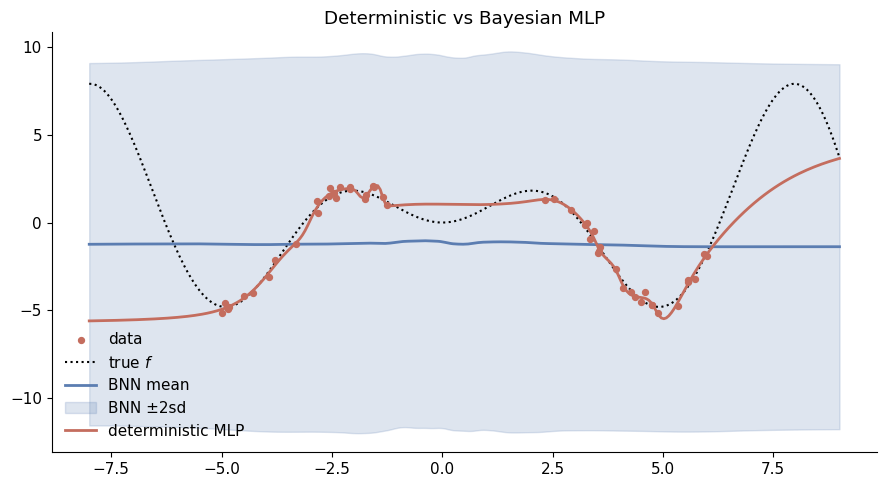

In [7]:
det = nn.Sequential(nn.Linear(1, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1))
opt_d = torch.optim.Adam(det.parameters(), lr=5e-3)
for _ in range(3000):
    opt_d.zero_grad()
    loss = ((det(X) - y)**2).mean()
    loss.backward(); opt_d.step()
with torch.no_grad():
    pred_det = det(Xs).squeeze().numpy()

plt.figure()
plt.scatter(X_np, y_np, color=RED, s=18, zorder=5, label='data')
plt.plot(xs_np, f_true(xs_np), 'k:', label='true $f$')
plt.plot(xs_np, mu, color=BLUE, lw=2, label='BNN mean')
plt.fill_between(xs_np, mu - 2*sd_total, mu + 2*sd_total,
                 color=BLUE, alpha=0.2, label='BNN ±2sd')
plt.plot(xs_np, pred_det, color=RED, lw=2, label='deterministic MLP')
plt.legend(frameon=False)
plt.title('Deterministic vs Bayesian MLP')
plt.tight_layout(); plt.show()


## 7. Summary

- Bayes-by-backprop is a clean, gradient-based recipe for training BNNs.
- The mean-field posterior is crude but yields useful uncertainty estimates, especially in extrapolation regions.
- A deterministic MLP has no way to know it does not know.

---

## Exercises

1. Replace the Gaussian prior with a **scale-mixture-of-Gaussians** prior (Blundell et al. 2015 §3.3). Compare predictive log-likelihood on held-out test data.
2. Implement a **local reparameterisation trick** that samples pre-activations instead of weights, reducing variance.
3. Run the same problem with a $\sigma_0 = 0.1$ prior and observe under-fitting; with $\sigma_0 = 10$ and observe near-deterministic behaviour. Explain.
4. Combine your BNN with the calibration metrics from notebook 6.3 and produce a reliability diagram.
